In [1]:
import utils
import numpy as np
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('display.max_rows', None)

# Adjust simulations
- Check MI Skin and Brain to see if it's below 1.9
- Check CEM43 skin and brain to see if it's below 0.25
- Check if maxT skin and brain exceeds 39 degrees Celsius

In [2]:
unique_subject_ids = [5, 10, 14, 15, 16, 20, 22, 23, 25, 28, 29, 37]

simulation_directory = f'/Volumes/project/3025011.02/TUS_simulations/planning/'
stimulation_limits_exceeded = False

stimulation_output_full_filenames_1 = os.path.join(simulation_directory, '**', '*layered_output_table_target_1*.csv')
stimulation_output_full_filenames_2 = os.path.join(simulation_directory, '**', '*layered_output_table_target_2*.csv')
stimulation_output_full_filenames_3 = os.path.join(simulation_directory, '**', '*layered_output_table_target_3*.csv')

simulation_output_full_filenames = glob.glob(stimulation_output_full_filenames_1, recursive=True) + glob.glob(stimulation_output_full_filenames_2, recursive=True) + glob.glob(stimulation_output_full_filenames_3, recursive=True)

# Adjust this so that all subjects are included
simulation_output_full_filenames = [s for s in simulation_output_full_filenames if any(f'sub-{subject_id:03}' in s for subject_id in unique_subject_ids)]
if not simulation_output_full_filenames:
    raise Exception('No simulations found')
simulation_output_full_filenames.sort()
print(simulation_output_full_filenames)

['/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-005/sub-005_layered_output_table_target_1_1_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-010/sub-010_layered_output_table_target_1_1_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-014/sub-014_layered_output_table_target_1_1_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-015/sub-015_layered_output_table_target_1_1_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-016/sub-016_layered_output_table_target_1_1_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-020/sub-020_layered_output_table_target_1_1_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-022/sub-022_layered_output_table_target_1_1_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/

### Check if target names are missing

In [3]:
expected = [f"target_{i}_{j}"
            for i in range(1, 4)
            for j in range(1, 7)]

# find which expected names are missing
missing = [t for t in expected
           if not any(t in filename for filename in simulation_output_full_filenames)]

if missing:
    print("Missing target names:")
    for name in missing:
        print("  -", name)
else:
    print("All target names 1_1 through 3_6 are present.")

All target names 1_1 through 3_6 are present.


In [4]:
# List to hold individual dataframes
list_of_dataframes = []

# Process each CSV file
for simulation_output_full_filename in simulation_output_full_filenames:
    # Extract the filename (without the path)
    stimulation_output_filename = os.path.basename(simulation_output_full_filename)
    # Remove the '.csv' extension
    stimulation_output_filename_without_extension = os.path.splitext(stimulation_output_filename)[0]

    # Split the filename by underscores
    stimulation_output_filename_parts = stimulation_output_filename_without_extension.split('_')

    # Extract the subject_id and target from the filename parts
    subject_id = stimulation_output_filename_parts[0]
    target = '_'.join(stimulation_output_filename_parts[4:7])

    # Read the CSV file (assuming it contains one row)
    try:
        df = pd.read_csv(simulation_output_full_filename)
    except Exception as e:
        print(f"Error reading {simulation_output_full_filename}: {e}")
        continue  # Skip this file if there's an error

    # Add the intensity and duty cycle based on the filename parts
    df['target'] = target
    if 'target_3' in target:
        df['intensity'] = 'strength_1'
        df['duty_cycle'] = 'dc20'
    else:
        duty_cycle = stimulation_output_filename_parts[7]
        intensity = '_'.join(stimulation_output_filename_parts[8:10])
        df['intensity'] = intensity
        df['duty_cycle'] = duty_cycle

    # Append the dataframe to the list
    list_of_dataframes.append(df)

# Combine all dataframes into one
if list_of_dataframes:
    stimulation_output = pd.concat(list_of_dataframes, ignore_index=True)
    print(stimulation_output)
else:
    raise Exception("No CSV files were found or processed.")

     subject_id  max_Isppa  max_Isppa_after_exit_plane  real_focal_distance  \
0             5   19.98381                   19.983810            53.002358   
1            10   13.96291                   13.962910            70.501773   
2            14   13.24534                   13.245340            61.010245   
3            15   11.08448                   11.084480            27.950850   
4            16   11.49961                   11.499610            23.135471   
5            20   18.07130                   18.071300            24.505102   
6            22   11.89942                   11.899420            28.178006   
7            23   15.23265                   15.232650            25.504901   
8            25   12.67687                   12.676870            27.789386   
9            28   13.47719                   13.477190            24.505102   
10           29   10.71090                   10.710900            29.008619   
11           37   13.31640                   12.8151

In [5]:
# Reorder columns
column_indices = list(range(stimulation_output.shape[1]))
reordered_column_indices = [column_indices[0]] + column_indices[-3:] + column_indices[1:-3]
stimulation_output = stimulation_output.iloc[:, reordered_column_indices]
stimulation_output.sort_values(by=['subject_id', 'target', 'intensity', 'duty_cycle'], inplace=True)
stimulation_output.reset_index(drop=True, inplace=True)
stimulation_output['CEM43_brain_skin'] = stimulation_output[['CEM43_brain', 'CEM43_skin']].max(axis=1)
# Replace values to improve readability
stimulation_output['duty_cycle'] = stimulation_output['duty_cycle'].map({'dc10': '10%', 'dc15': '15%', 'dc20': '20%'})
stimulation_output['intensity'] = stimulation_output['intensity'].map({'strength_1': '35', 'strength_2': '63', 'strength_3': '81', 'strength_4': '110'})
# Now drop some columns
stimulation_output.drop(
    ['real_focal_distance','Ix_brain', 'Iy_brain','Iz_brain',
     'max_pressure_brain','max_pressure_skull','max_pressure_skin',
     'riseT_brain', 'riseT_skull', 'riseT_skin','isppa_at_target',
     'max_Isppa','half_max_ISPPA_volume_brain','avg_isppa_around_target',
     'focus_pos_final_1', 'focus_pos_final_2', 'focus_pos_final_3',
     'trans_pos_final_1', 'trans_pos_final_2', 'trans_pos_final_3'],
    axis=1,
    inplace=True
)

print(stimulation_output)

     subject_id      target intensity duty_cycle  max_Isppa_after_exit_plane  \
0             5  target_1_1        35        20%                   19.983810   
1             5  target_1_2        35        20%                   24.353930   
2             5  target_1_3        35        20%                   19.983810   
3             5  target_1_4        35        20%                   24.353930   
4             5  target_1_5        35        20%                   19.983810   
5             5  target_1_6        35        20%                   24.353930   
6             5  target_2_1        81        20%                   16.564620   
7             5  target_2_2        81        20%                   13.242560   
8             5  target_2_3        81        20%                   18.932540   
9             5  target_2_4        81        20%                   17.769520   
10            5  target_2_5        81        20%                   28.777860   
11            5  target_2_6        81   

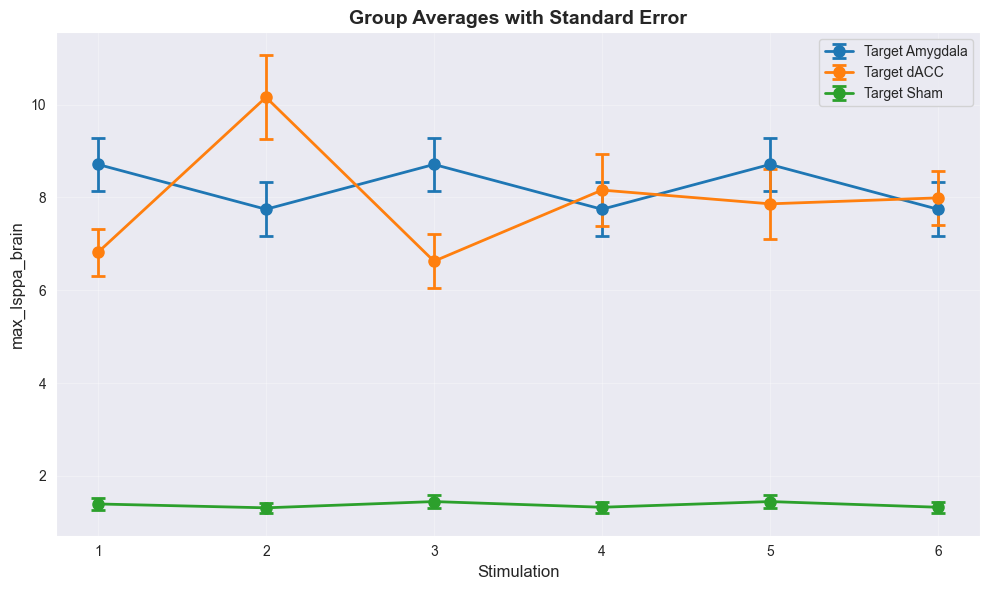

In [15]:
def plot_group_averages(df, value_column='value'):
    """
    Plot average and standard error for groups based on 'target' column.

    Parameters:
    -----------
    df : pandas DataFrame
        DataFrame with 'target' column (format: 'target_X_Y' where X is group, Y is point)
        and a value column to plot
    value_column : str
        Name of the column containing the values to plot (default: 'value')
    """
    # Parse the target column to extract group and point
    df['group'] = df['target'].str.extract(r'target_(\d+)_\d+')[0].astype(int)
    df['point'] = df['target'].str.extract(r'target_\d+_(\d+)')[0].astype(int)

    # Calculate mean and standard error for each group-point combination
    grouped = df.groupby(['group', 'point'])[value_column].agg(['mean', 'sem']).reset_index()

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))

    targets = ['Amygdala', 'dACC', 'Sham']

    # Plot each group
    for group in sorted(grouped['group'].unique()):
        group_data = grouped[grouped['group'] == group]
        ax.errorbar(group_data['point'], group_data['mean'],
                   yerr=group_data['sem'],
                   marker='o', capsize=5, capthick=2,
                   label=f'Target {targets[group-1]}', linewidth=2, markersize=8)

    ax.set_xlabel('Stimulation', fontsize=12)
    ax.set_ylabel(value_column, fontsize=12)
    ax.set_title('Group Averages with Standard Error', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig, ax


# Example usage:
# Create sample data
np.random.seed(42)
sample_data = []
for group in [1, 2, 3]:
    for point in [1, 2, 3, 4, 5, 6]:
        # Generate multiple observations per target for calculating SE
        for rep in range(5):
            sample_data.append({
                'target': f'target_{group}_{point}',
                'value': np.random.randn() + group * 0.5 + point * 0.2
            })

# Plot
fig, ax = plot_group_averages(stimulation_output, value_column='max_Isppa_brain')
plt.show()

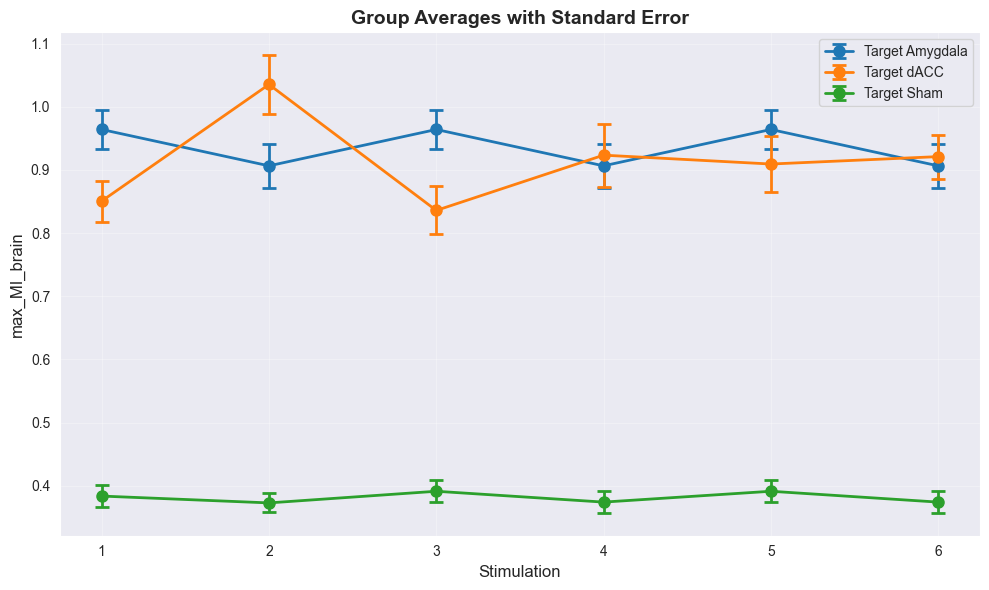

In [16]:
def plot_group_averages(df, value_column='value'):
    """
    Plot average and standard error for groups based on 'target' column.

    Parameters:
    -----------
    df : pandas DataFrame
        DataFrame with 'target' column (format: 'target_X_Y' where X is group, Y is point)
        and a value column to plot
    value_column : str
        Name of the column containing the values to plot (default: 'value')
    """
    # Parse the target column to extract group and point
    df['group'] = df['target'].str.extract(r'target_(\d+)_\d+')[0].astype(int)
    df['point'] = df['target'].str.extract(r'target_\d+_(\d+)')[0].astype(int)

    # Calculate mean and standard error for each group-point combination
    grouped = df.groupby(['group', 'point'])[value_column].agg(['mean', 'sem']).reset_index()

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))

    targets = ['Amygdala', 'dACC', 'Sham']

    # Plot each group
    for group in sorted(grouped['group'].unique()):
        group_data = grouped[grouped['group'] == group]
        ax.errorbar(group_data['point'], group_data['mean'],
                   yerr=group_data['sem'],
                   marker='o', capsize=5, capthick=2,
                   label=f'Target {targets[group-1]}', linewidth=2, markersize=8)

    ax.set_xlabel('Stimulation', fontsize=12)
    ax.set_ylabel(value_column, fontsize=12)
    ax.set_title('Group Averages with Standard Error', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig, ax


# Example usage:
# Create sample data
np.random.seed(42)
sample_data = []
for group in [1, 2, 3]:
    for point in [1, 2, 3, 4, 5, 6]:
        # Generate multiple observations per target for calculating SE
        for rep in range(5):
            sample_data.append({
                'target': f'target_{group}_{point}',
                'value': np.random.randn() + group * 0.5 + point * 0.2
            })

# Plot
fig, ax = plot_group_averages(stimulation_output, value_column='max_MI_brain')
plt.show()

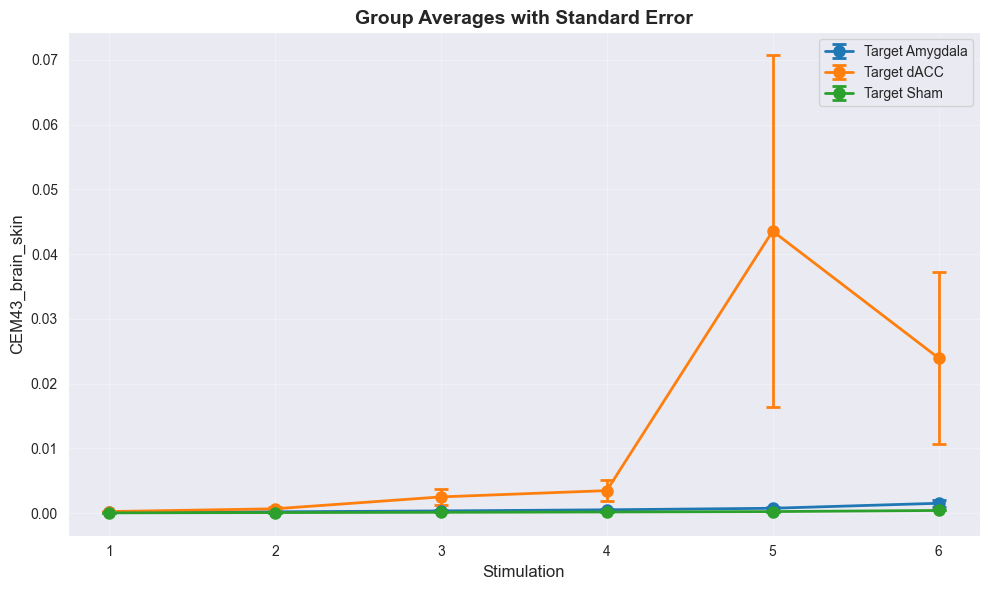

In [17]:
def plot_group_averages(df, value_column='value'):
    """
    Plot average and standard error for groups based on 'target' column.

    Parameters:
    -----------
    df : pandas DataFrame
        DataFrame with 'target' column (format: 'target_X_Y' where X is group, Y is point)
        and a value column to plot
    value_column : str
        Name of the column containing the values to plot (default: 'value')
    """
    # Parse the target column to extract group and point
    df['group'] = df['target'].str.extract(r'target_(\d+)_\d+')[0].astype(int)
    df['point'] = df['target'].str.extract(r'target_\d+_(\d+)')[0].astype(int)

    # Calculate mean and standard error for each group-point combination
    grouped = df.groupby(['group', 'point'])[value_column].agg(['mean', 'sem']).reset_index()

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))

    targets = ['Amygdala', 'dACC', 'Sham']

    # Plot each group
    for group in sorted(grouped['group'].unique()):
        group_data = grouped[grouped['group'] == group]
        ax.errorbar(group_data['point'], group_data['mean'],
                   yerr=group_data['sem'],
                   marker='o', capsize=5, capthick=2,
                   label=f'Target {targets[group-1]}', linewidth=2, markersize=8)

    ax.set_xlabel('Stimulation', fontsize=12)
    ax.set_ylabel(value_column, fontsize=12)
    ax.set_title('Group Averages with Standard Error', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig, ax


# Example usage:
# Create sample data
np.random.seed(42)
sample_data = []
for group in [1, 2, 3]:
    for point in [1, 2, 3, 4, 5, 6]:
        # Generate multiple observations per target for calculating SE
        for rep in range(5):
            sample_data.append({
                'target': f'target_{group}_{point}',
                'value': np.random.randn() + group * 0.5 + point * 0.2
            })

# Plot
fig, ax = plot_group_averages(stimulation_output, value_column='CEM43_brain_skin')
plt.show()